In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/cleaned_crime_nbh_2024.csv")

In [2]:
df.shape

(14494, 124)

In [5]:
df.columns

Index(['gwb_code_10', 'regio', 'gm_naam', 'ind_wbi', 'a_inw', 'a_man',
       'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44',
       ...
       'g_afs_sc', 'g_3km_sc', 'a_opp_ha', 'a_lan_ha', 'a_wat_ha', 'pst_mvp',
       'pst_dekp', 'ste_mvs', 'ste_oad', 'GeregistreerdeMisdrijven_1'],
      dtype='object', length=124)

### Removing columns with > 20% missing values

In [69]:
missing_20 = df.loc[:, df.isna().mean() >= 0.2]
missing_20.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14494 entries, 0 to 14493
Empty DataFrame


In [70]:
# Save all columns with > 20% missing values as a variable
missing_20 = df.columns[df.isna().mean() >= 0.2].tolist()
for col in missing_20:
    print(col)

In [72]:
df = df.drop(columns=missing_20)

In [73]:
df.shape

(14494, 90)

In [80]:
missing = df.isna().mean().sort_values(ascending=False)

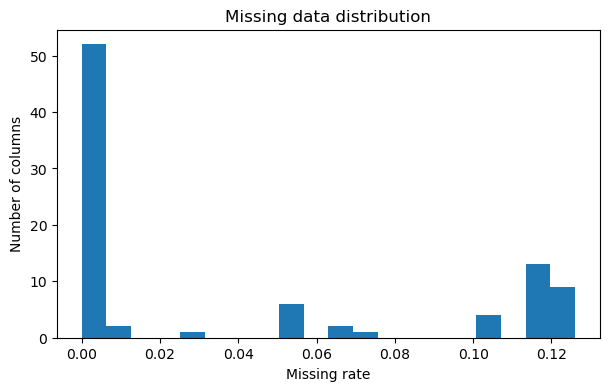

In [86]:
plt.figure(figsize=(7,4))
plt.hist(missing, bins=20)
plt.title("Missing data distribution")
plt.xlabel("Missing rate")
plt.ylabel("Number of columns")
plt.show()

### Imputing columns with < 20% missing values